# WEC Power Estimation: Leixões Sea-State Characterization and Generic Power Matrix

This notebook uses the processed Leixões buoy sea-state table prepared in [Notebook 01](01_wave_data_preparation.ipynb).

The goal is to explore the available wave-height, period, direction, and extreme-wave variables before converting the sea-state record into a simplified estimated WEC electrical power signal.

The notebook is organized in three phases:

1. **Site characterization** — visualize the observed wave conditions and directionality.
2. **Sea-state consistency and operating-condition checks** — compare related height and period variables and define simple flags for interpretation.
3. **Simplified WEC electrical power estimation** — use a generic power-matrix-style approach to estimate an illustrative WEC power-output signal.

The estimated WEC power signal is intended for later forecasting, uncertainty, and storage-smoothing examples. It is not a validated device model or detailed WEC hydrodynamic simulation.


## Phase 1 — Site characterization

This phase gives a first visual overview of the Leixões buoy sea-state record prepared in [Notebook 01](01_wave_data_preparation.ipynb).

We start with the two main variables that will later drive the simplified WEC power estimate:

- `hm0_m`: spectral significant wave height
- `tp_s`: peak wave period

Missing values are kept as gaps in the plots.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mhkit.wave import graphics as wave_graphics

# Paths
PROCESSED_DATA_PATH = Path("../data/processed/leixoes_wave_30min_processed.parquet")
FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load processed sea-state table from Notebook 01
wave_df = pd.read_parquet(PROCESSED_DATA_PATH)

wave_df["time"] = pd.to_datetime(wave_df["time"])
wave_df = wave_df.sort_values("time").reset_index(drop=True)

### Time series overview of wave height and peak period

This plot shows how significant wave height and peak period vary through the available February–June 2025 record.

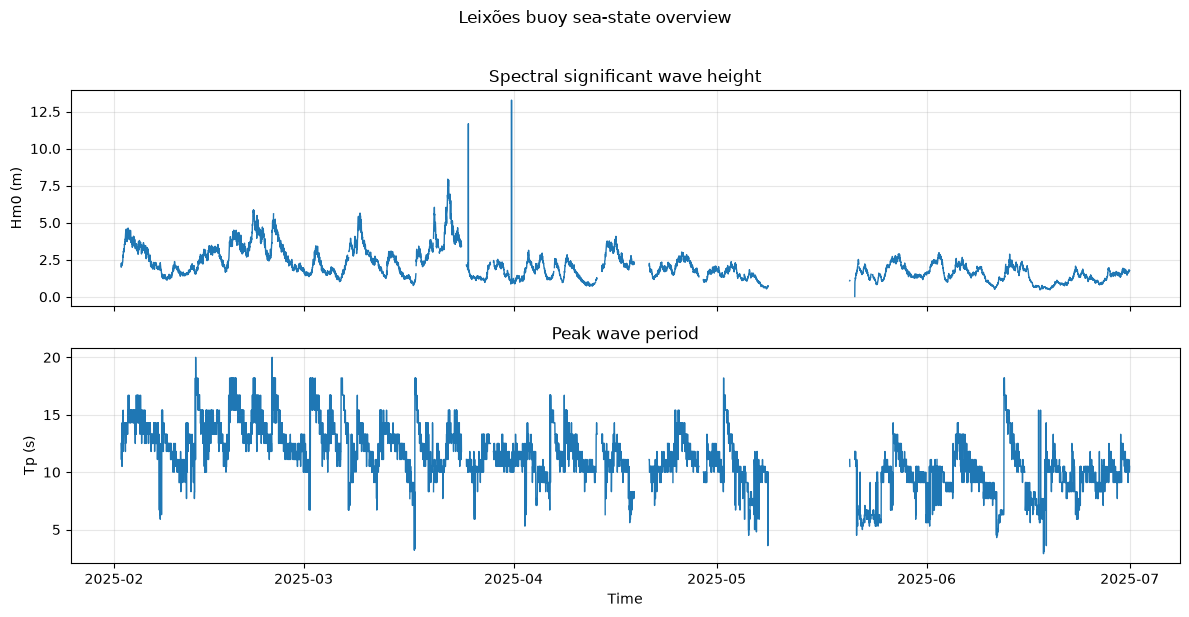

In [2]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 6),
    sharex=True,
)

axes[0].plot(wave_df["time"], wave_df["hm0_m"], linewidth=1.0)
axes[0].set_ylabel("Hm0 (m)")
axes[0].set_title("Spectral significant wave height")

axes[1].plot(wave_df["time"], wave_df["tp_s"], linewidth=1.0)
axes[1].set_ylabel("Tp (s)")
axes[1].set_xlabel("Time")
axes[1].set_title("Peak wave period")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Leixões buoy sea-state overview", y=1.02)
fig.tight_layout()

plt.show()

### Sea-state cloud: wave height versus peak period

The simplified WEC power estimate will mainly depend on wave height and wave period.  
This scatter plot shows the observed `hm0_m`–`tp_s` combinations in the Leixões record.

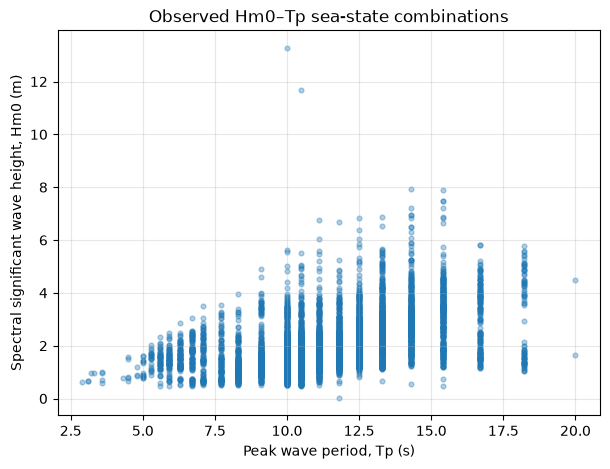

In [3]:
sea_state_df = wave_df.dropna(subset=["hm0_m", "tp_s"]).copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    sea_state_df["tp_s"],
    sea_state_df["hm0_m"],
    s=12,
    alpha=0.35,
)

ax.set_xlabel("Peak wave period, Tp (s)")
ax.set_ylabel("Spectral significant wave height, Hm0 (m)")
ax.set_title("Observed Hm0–Tp sea-state combinations")
ax.grid(True, alpha=0.3)

plt.show()

Most observed sea states are concentrated between about 5–17 s peak period and below roughly 5 m significant wave height. A few much larger wave-height values appear as energetic events or possible extremes in the record.

### Wave direction and directional spreading

Wave direction helps describe where the observed waves mainly come from.  
Here, a wave rose summarizes peak wave direction together with significant wave-height classes.

Directional spreading is shown separately because it describes how concentrated or broad the wave field is around the peak direction.

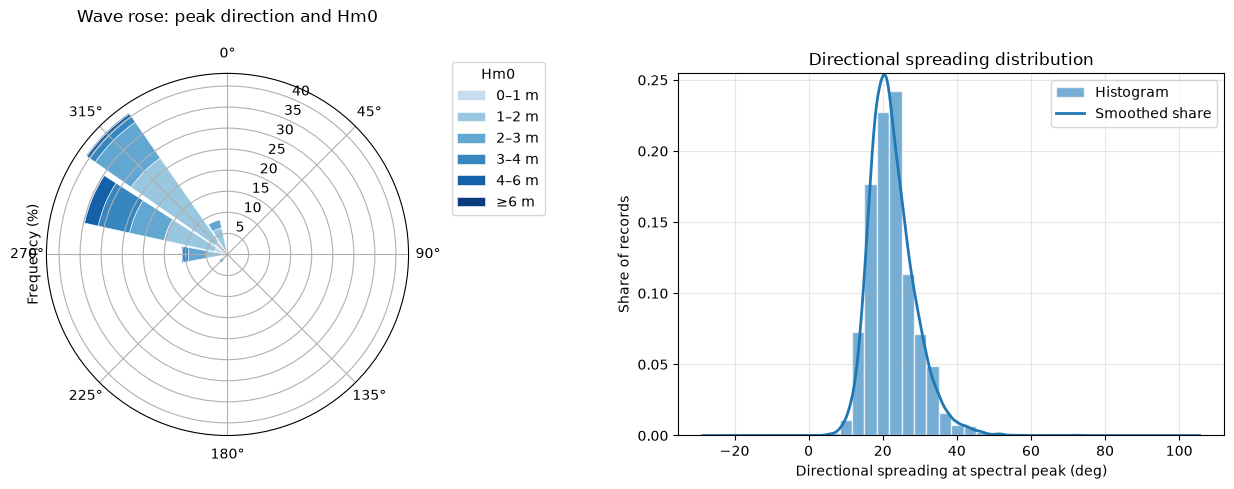

In [4]:
direction_df = wave_df.dropna(subset=["dir_peak_deg", "hm0_m"]).copy()
spread_df = wave_df.dropna(subset=["spread_peak_deg"]).copy()

# Direction is circular, so keep values in [0, 360).
direction_df["dir_peak_deg"] = direction_df["dir_peak_deg"] % 360

# Direction sectors for the rose plot.
sector_width_deg = 22.5
direction_centers = np.arange(0, 360, sector_width_deg)

direction_bin_idx = np.floor(
    ((direction_df["dir_peak_deg"] + sector_width_deg / 2) % 360) / sector_width_deg
).astype(int)

direction_df["direction_bin_deg"] = direction_bin_idx * sector_width_deg

# Wave-height classes.
hm0_bins = [0, 1, 2, 3, 4, 6, np.inf]
hm0_labels = ["0–1 m", "1–2 m", "2–3 m", "3–4 m", "4–6 m", "≥6 m"]

direction_df["hm0_class"] = pd.cut(
    direction_df["hm0_m"],
    bins=hm0_bins,
    labels=hm0_labels,
    right=False,
)

rose_counts = pd.crosstab(
    direction_df["direction_bin_deg"],
    direction_df["hm0_class"],
)

rose_counts = rose_counts.reindex(
    index=direction_centers,
    columns=hm0_labels,
    fill_value=0,
)

rose_freq = 100 * rose_counts / rose_counts.values.sum()

# Light-to-dark blue colors for increasing Hm0 classes.
hm0_colors = plt.cm.Blues(np.linspace(0.25, 0.95, len(hm0_labels)))

fig = plt.figure(figsize=(13, 5))

# Wave rose
ax1 = fig.add_subplot(1, 2, 1, projection="polar")

theta = np.deg2rad(direction_centers)
bar_width = np.deg2rad(sector_width_deg * 0.9)
bottom = np.zeros(len(direction_centers))

for hm0_class, color in zip(hm0_labels, hm0_colors):
    values = rose_freq[hm0_class].values
    ax1.bar(
        theta,
        values,
        width=bar_width,
        bottom=bottom,
        label=hm0_class,
        color=color,
        edgecolor="white",
        linewidth=0.4,
    )
    bottom += values

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_title("Wave rose: peak direction and Hm0", pad=18)
ax1.set_ylabel("Frequency (%)")
ax1.legend(title="Hm0", bbox_to_anchor=(1.10, 1.05), loc="upper left")

# Directional spreading histogram + smoothed share curve
ax2 = fig.add_subplot(1, 2, 2)

spread_values = spread_df["spread_peak_deg"].dropna()

spread_bins = np.linspace(
    spread_values.min(),
    spread_values.max(),
    21,
)

spread_bin_width = spread_bins[1] - spread_bins[0]
spread_weights = np.ones(len(spread_values)) / len(spread_values)

ax2.hist(
    spread_values,
    bins=spread_bins,
    weights=spread_weights,
    color=plt.cm.Blues(0.65),
    edgecolor="white",
    alpha=0.7,
    label="Histogram",
)

spread_values.plot.kde(
    ax=ax2,
    linewidth=2,
    label="Smoothed share",
)

kde_line = ax2.lines[-1]
kde_line.set_ydata(kde_line.get_ydata() * spread_bin_width)

ax2.set_xlabel("Directional spreading at spectral peak (deg)")
ax2.set_ylabel("Share of records")
ax2.set_title("Directional spreading distribution")
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True)

fig.tight_layout()
figure_path = FIGURE_DIR / "02_leixoes_wave_rose_directional_spreading.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

The wave rose shows that most recorded peak wave directions are concentrated around the northwest sector, with larger wave-height classes also appearing mainly from that direction. The spreading distribution is centred around roughly 20–30°, suggesting that many observed sea states have a fairly concentrated peak direction rather than very broad directional spreading.

## Phase 2 — Sea-state consistency and operating-condition checks

This phase compares related wave-height and wave-period variables before using them in the simplified WEC power-estimation step.

We start by checking how the main height variable `hm0_m` relates to the secondary and extreme-wave height variables.

### Wave-height variable checks

`hm0_m` is the main wave-height variable used later.  
Here it is compared with:

- `h13_m`: average height of the highest one-third waves
- `hmax_m`: maximum zero-crossing wave height

These plots help check whether the related height variables behave consistently.

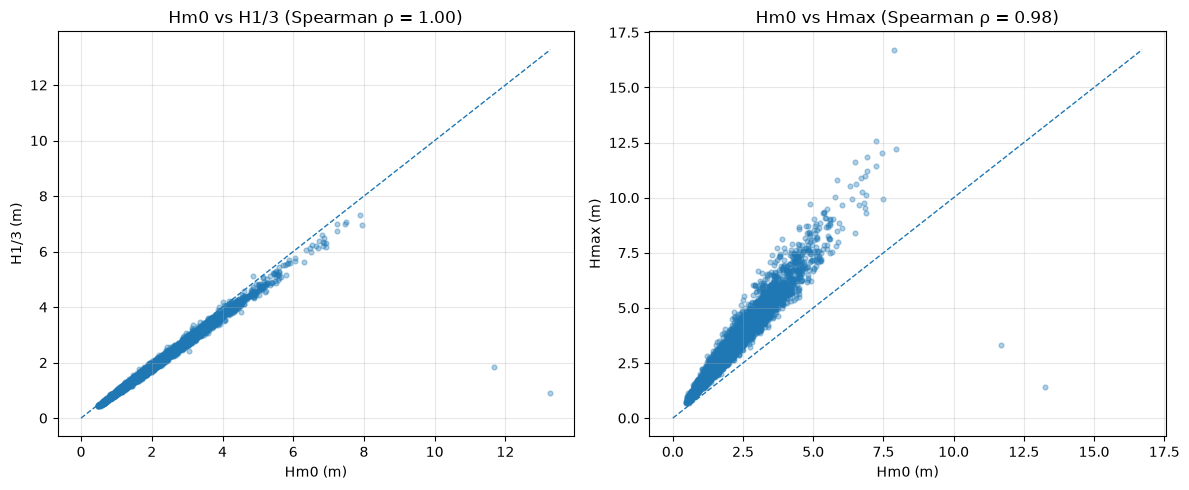

In [5]:
from scipy.stats import spearmanr

height_df = wave_df.dropna(subset=["hm0_m", "h13_m", "hmax_m"]).copy()

rho_h13, _ = spearmanr(height_df["hm0_m"], height_df["h13_m"])
rho_hmax, _ = spearmanr(height_df["hm0_m"], height_df["hmax_m"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hm0 vs H1/3
axes[0].scatter(
    height_df["hm0_m"],
    height_df["h13_m"],
    s=12,
    alpha=0.35,
)

max_h13 = np.nanmax([height_df["hm0_m"].max(), height_df["h13_m"].max()])
axes[0].plot([0, max_h13], [0, max_h13], linestyle="--", linewidth=1)

axes[0].set_xlabel("Hm0 (m)")
axes[0].set_ylabel("H1/3 (m)")
axes[0].set_title(f"Hm0 vs H1/3 (Spearman ρ = {rho_h13:.2f})")
axes[0].grid(True, alpha=0.3)

# Hm0 vs Hmax
axes[1].scatter(
    height_df["hm0_m"],
    height_df["hmax_m"],
    s=12,
    alpha=0.35,
)

max_hmax = np.nanmax([height_df["hm0_m"].max(), height_df["hmax_m"].max()])
axes[1].plot([0, max_hmax], [0, max_hmax], linestyle="--", linewidth=1)

axes[1].set_xlabel("Hm0 (m)")
axes[1].set_ylabel("Hmax (m)")
axes[1].set_title(f"Hm0 vs Hmax (Spearman ρ = {rho_hmax:.2f})")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

`hm0_m` and `h13_m` are almost identical in rank order, which is expected because both describe significant wave-height scale. `hmax_m` is also strongly related to `hm0_m`, but it is generally larger and more scattered because it represents maximum individual wave height rather than the average sea-state height.

### Wave-period variable checks

`tp_s` is the main period variable available for the later simplified WEC estimate.  
Here it is compared with two secondary period descriptors:

- `tm02_s`: spectral moments `(0,2)` wave period
- `tz_s`: average zero-crossing wave period

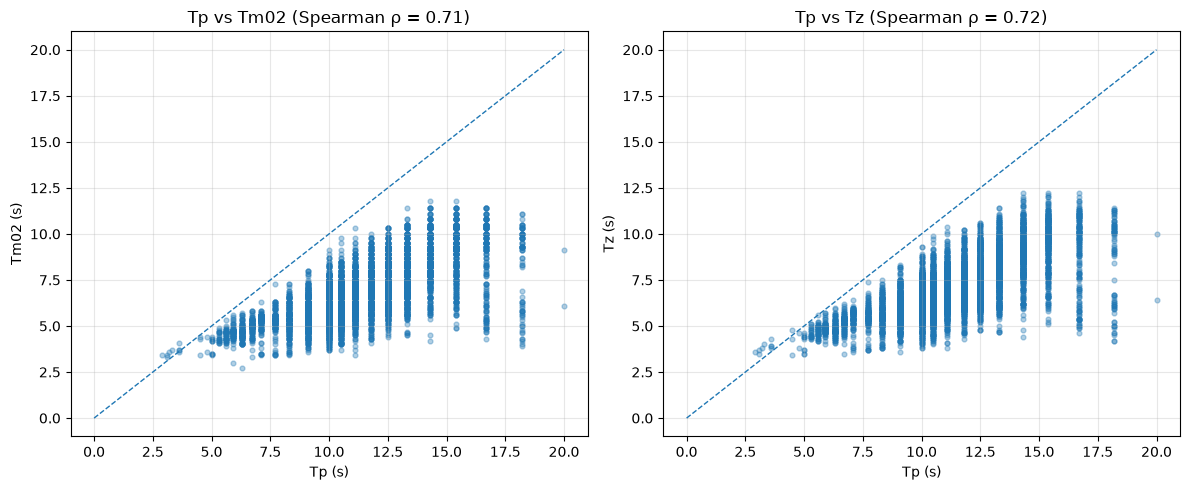

In [6]:
period_df = wave_df.dropna(subset=["tp_s", "tm02_s", "tz_s"]).copy()

rho_tm02, _ = spearmanr(period_df["tp_s"], period_df["tm02_s"])
rho_tz, _ = spearmanr(period_df["tp_s"], period_df["tz_s"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tp vs Tm02
axes[0].scatter(
    period_df["tp_s"],
    period_df["tm02_s"],
    s=12,
    alpha=0.35,
)

max_tm02 = np.nanmax([period_df["tp_s"].max(), period_df["tm02_s"].max()])
axes[0].plot([0, max_tm02], [0, max_tm02], linestyle="--", linewidth=1)

axes[0].set_xlabel("Tp (s)")
axes[0].set_ylabel("Tm02 (s)")
axes[0].set_title(f"Tp vs Tm02 (Spearman ρ = {rho_tm02:.2f})")
axes[0].grid(True, alpha=0.3)

# Tp vs Tz
axes[1].scatter(
    period_df["tp_s"],
    period_df["tz_s"],
    s=12,
    alpha=0.35,
)

max_tz = np.nanmax([period_df["tp_s"].max(), period_df["tz_s"].max()])
axes[1].plot([0, max_tz], [0, max_tz], linestyle="--", linewidth=1)

axes[1].set_xlabel("Tp (s)")
axes[1].set_ylabel("Tz (s)")
axes[1].set_title(f"Tp vs Tz (Spearman ρ = {rho_tz:.2f})")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

`tm02_s` and `tz_s` are both shorter-period descriptors than `tp_s`. `tp_s` is the period at the spectral peak, while `tm02_s` is a spectral-moment-based mean period and `tz_s` is the average zero-crossing period. Both variables increase broadly with `tp_s`, but the relationship is more scattered than for the height variables. This is expected because peak period describes the dominant wave component, while mean/zero-crossing periods summarize the broader sea state.

### Simple wave-height condition flags

Before estimating WEC power, we define a few simple wave-height flags for interpretation.

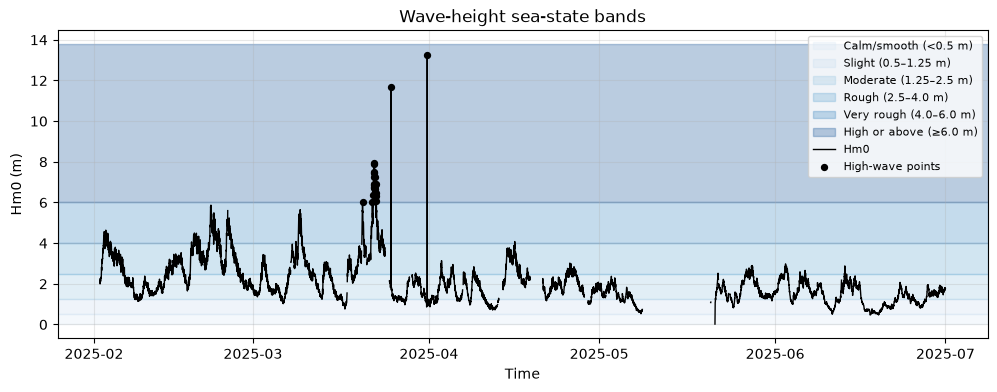

In [7]:
condition_df = wave_df.copy()

# Descriptive sea-state bands based on common WMO/Douglas-style Hs ranges.
sea_state_bands = [
    (0.0, 0.5, "Calm/smooth (<0.5 m)", plt.cm.Blues(0.15)),
    (0.5, 1.25, "Slight (0.5–1.25 m)", plt.cm.Blues(0.25)),
    (1.25, 2.5, "Moderate (1.25–2.5 m)", plt.cm.Blues(0.40)),
    (2.5, 4.0, "Rough (2.5–4.0 m)", plt.cm.Blues(0.55)),
    (4.0, 6.0, "Very rough (4.0–6.0 m)", plt.cm.Blues(0.70)),
    (6.0, np.nanmax(condition_df["hm0_m"]) + 0.5, "High or above (≥6.0 m)", plt.cm.Blues(0.90)),
]

condition_df["high_wave_flag"] = condition_df["hm0_m"] >= 6.0

fig, ax = plt.subplots(figsize=(12, 4))

# Background sea-state bands
for lower, upper, label, color in sea_state_bands:
    ax.axhspan(
        lower,
        upper,
        color=color,
        alpha=0.28,
        label=label,
    )

# Main Hm0 line
ax.plot(
    condition_df["time"],
    condition_df["hm0_m"],
    color="black",
    linewidth=1.0,
    label="Hm0",
)

# High-wave points
ax.scatter(
    condition_df.loc[condition_df["high_wave_flag"], "time"],
    condition_df.loc[condition_df["high_wave_flag"], "hm0_m"],
    s=18,
    color="black",
    zorder=3,
    label="High-wave points",
)

ax.set_xlabel("Time")
ax.set_ylabel("Hm0 (m)")
ax.set_title("Wave-height sea-state bands")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)
figure_path = FIGURE_DIR / "02_leixoes_hm0_sea_state_bands.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

This plot uses descriptive sea-state bands based on common [WMO/Douglas-style significant-wave-height ranges](https://www.nodc.noaa.gov/gtspp/document/codetbls/wmocodes/table3700.html). These bands are used only to interpret the observed wave record; they are not WEC operating limits.

Most of the record falls within the slight to rough ranges, with fewer periods reaching the very rough and high-wave bands. The highest wave events appear concentrated around late March to early April.

### Adding descriptive sea-state flags

The sea-state bands are kept as simple descriptive labels.  
They may help later when interpreting estimated WEC power values, but they are not device-specific operating limits.

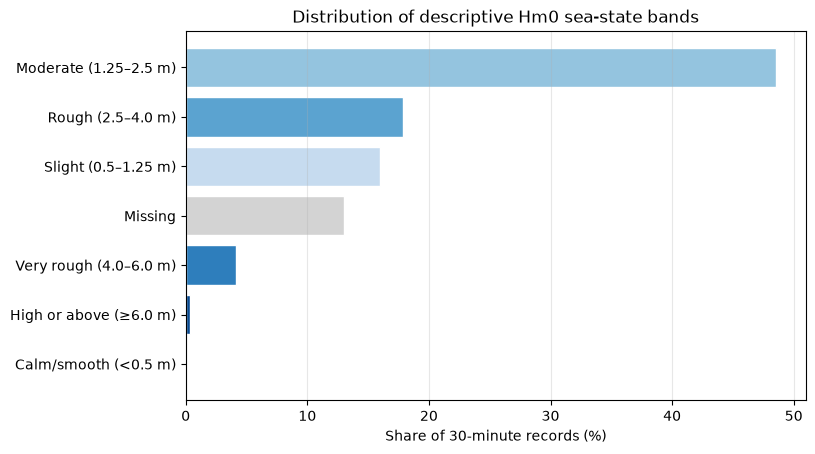

In [8]:
# Keep descriptive sea-state labels in the main dataframe.
sea_state_bins = [0.0, 0.5, 1.25, 2.5, 4.0, 6.0, np.inf]

sea_state_labels = [
    "calm_smooth",
    "slight",
    "moderate",
    "rough",
    "very_rough",
    "high_or_above",
]

sea_state_display_labels = {
    "calm_smooth": "Calm/smooth (<0.5 m)",
    "slight": "Slight (0.5–1.25 m)",
    "moderate": "Moderate (1.25–2.5 m)",
    "rough": "Rough (2.5–4.0 m)",
    "very_rough": "Very rough (4.0–6.0 m)",
    "high_or_above": "High or above (≥6.0 m)",
    "missing": "Missing",
}

sea_state_colors = {
    "calm_smooth": plt.cm.Blues(0.15),
    "slight": plt.cm.Blues(0.25),
    "moderate": plt.cm.Blues(0.40),
    "rough": plt.cm.Blues(0.55),
    "very_rough": plt.cm.Blues(0.70),
    "high_or_above": plt.cm.Blues(0.90),
    "missing": "lightgrey",
}

wave_df["sea_state_hm0_band"] = pd.cut(
    wave_df["hm0_m"],
    bins=sea_state_bins,
    labels=sea_state_labels,
    right=False,
)

wave_df["high_wave_flag"] = wave_df["hm0_m"] >= 6.0
wave_df["very_rough_or_higher_flag"] = wave_df["hm0_m"] >= 4.0

sea_state_counts = (
    wave_df["sea_state_hm0_band"]
    .astype(object)
    .where(wave_df["sea_state_hm0_band"].notna(), "missing")
    .value_counts()
)

sea_state_percent = 100 * sea_state_counts / len(wave_df)

sea_state_summary = (
    pd.DataFrame(
        {
            "band": sea_state_counts.index,
            "count": sea_state_counts.values,
            "percent": sea_state_percent.values,
        }
    )
    .sort_values("percent", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.barh(
    sea_state_summary["band"].map(sea_state_display_labels),
    sea_state_summary["percent"],
    color=sea_state_summary["band"].map(sea_state_colors),
    edgecolor="white",
)

ax.set_xlabel("Share of 30-minute records (%)")
ax.set_ylabel("")
ax.set_title("Distribution of descriptive Hm0 sea-state bands")
ax.grid(True, axis="x", alpha=0.3)
figure_path = FIGURE_DIR / "02_leixoes_hm0_sea_state_band_distribution.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

## Phase 3 — Simplified WEC electrical power estimation

This phase converts the cleaned sea-state record into an illustrative WEC electrical power estimate.

Because the processed buoy table does not include full wave spectra or measured WEC power, this notebook uses a simplified power-matrix-style approach. The result is a transparent estimated power signal for later forecasting and storage-smoothing examples, not a validated device model.

### Approximate energy period `te_approx_s` and wave power flux

A WEC power matrix is commonly described using wave height and a wave-period variable.  
Here, `tp_s` is the available peak-period measurement. Because the direct energy period was not available in the processed buoy data, an approximate energy period `te_approx_s` is derived from `tp_s`.

For a Pierson–Moskowitz-type spectrum, a commonly used approximation is:

$$
T_e \approx 0.86\,T_p
$$

The exact ratio depends on the wave spectrum; for example, Pierson–Moskowitz and JONSWAP assumptions can give different values. This approximation is therefore used only as a simple supporting variable for this workflow. See Guillou (2020) for discussion of estimating wave-energy flux from significant wave height and peak period, including the use of $( \alpha = 0.86 )$ for a Pierson–Moskowitz spectrum: [Estimating wave energy flux from significant wave height and peak period](https://doi.org/10.1016/j.renene.2020.03.124).

The approximate deep-water wave power flux is then estimated as:

$$
J \approx 0.49\,H_{m0}^{2}\,T_e
$$

where $J$ is in kW/m, $H_{m0}$ is in metres, and $T_e$ is in seconds.

The wave power flux estimate is used as a resource diagnostic, not as the final WEC electrical power.

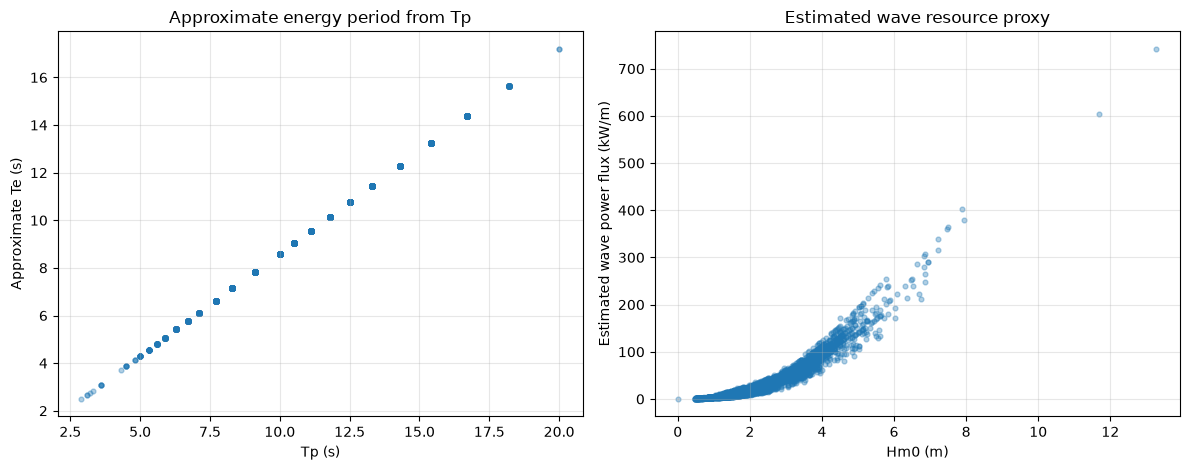

In [9]:
wec_df = wave_df.copy()

# Approximate energy period from peak period.
# This is a simple assumption because VTM10 / direct energy period was not available.
te_from_tp_factor = 0.86

wec_df["te_approx_s"] = te_from_tp_factor * wec_df["tp_s"]

# Deep-water wave power flux approximation:
# J [kW/m] ≈ 0.49 * Hm0^2 * Te
wec_df["wave_power_flux_kw_m_estimated"] = (
    0.49 * wec_df["hm0_m"] ** 2 * wec_df["te_approx_s"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Tp vs approximate Te
axes[0].scatter(
    wec_df["tp_s"],
    wec_df["te_approx_s"],
    s=12,
    alpha=0.35,
)

axes[0].set_xlabel("Tp (s)")
axes[0].set_ylabel("Approximate Te (s)")
axes[0].set_title("Approximate energy period from Tp")
axes[0].grid(True, alpha=0.3)

# Hm0 vs estimated wave power flux
axes[1].scatter(
    wec_df["hm0_m"],
    wec_df["wave_power_flux_kw_m_estimated"],
    s=12,
    alpha=0.35,
)

axes[1].set_xlabel("Hm0 (m)")
axes[1].set_ylabel("Estimated wave power flux (kW/m)")
axes[1].set_title("Estimated wave resource proxy")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Defining simplified WEC assumptions

The estimated WEC power signal is based on a generic illustrative response, not a specific device.

The assumptions below are chosen to stay within a realistic small/medium WEC scale while keeping the model transparent. A rated-power scale of 250 kW is consistent with published and database examples of devices such as AquaBuOY, which is commonly listed with a 250 kW rating. The Pelamis P-750 also used three 250 kW power-conversion modules, although the complete Pelamis device was rated at 750 kW.

The use of a power matrix is also consistent with common WEC performance-estimation practice. For example, Pelamis documentation describes a power matrix over significant wave height and power period, and several WEC assessment studies estimate converted power by combining buoy or hindcast sea states with device conversion matrices.

The high-wave threshold is treated as an illustrative power-limiting / cut-out threshold. It is loosely motivated by Pelamis documentation that reports hydrostatic power limiting above about 6–7 m significant wave height.

The remaining values, including the preferred period and response width, are modelling choices for this notebook. They are not calibrated to a validated device. They define a smooth generic response shape for creating a transparent power-like signal for later forecasting and storage-smoothing examples.

References:

- [AquaBuOY device entry, PRIMRE / OpenEI](https://openei.org/wiki/PRIMRE/Databases/Projects_Database/Devices/AquaBuOY)
- [Pelamis P-750 brochure](https://bravenewclimate.com/files/media/pelamisbrochure.pdf)
- [Assessment of WECs based on historical buoy data and conversion matrices](https://www.mdpi.com/2073-4441/15/23/4075)
- [Guillou 2020 — estimating wave energy flux from significant wave height and peak period](https://doi.org/10.1016/j.renene.2020.03.124)

In [10]:
from IPython.display import Markdown, display

# Generic illustrative WEC assumptions.
# These are modelling assumptions, not device-validated parameters.

wec_assumptions = {
    "rated_power_kw": 250.0,
    "cut_in_hm0_m": 0.5,
    "rated_hm0_m": 4.0,
    "storm_cutout_hm0_m": 6.0,
    "preferred_te_s": 9.0,
    "period_response_width_s": 2.5,
}

wec_assumptions_table = pd.DataFrame(
    {
        "Assumption": [
            "Rated electrical power",
            "Cut-in wave height",
            "Rated-response wave height",
            "High-wave limiting threshold",
            "Preferred energy period",
            "Period response width",
        ],
        "Value": [
            f"{wec_assumptions['rated_power_kw']:.0f} kW",
            f"{wec_assumptions['cut_in_hm0_m']:.1f} m",
            f"{wec_assumptions['rated_hm0_m']:.1f} m",
            f"{wec_assumptions['storm_cutout_hm0_m']:.1f} m",
            f"{wec_assumptions['preferred_te_s']:.1f} s",
            f"{wec_assumptions['period_response_width_s']:.1f} s",
        ],
        "Role": [
            "Upper limit for estimated electrical power",
            "Below this, estimated WEC power is set to zero",
            "Wave-height scale where output approaches rated power",
            "Above this, estimated WEC power is set to zero",
            "Period where the generic response is centred",
            "Controls how quickly response decreases away from the preferred period",
        ],
    }
)

display(Markdown(wec_assumptions_table.to_markdown(index=False)))

| Assumption                   | Value   | Role                                                                   |
|:-----------------------------|:--------|:-----------------------------------------------------------------------|
| Rated electrical power       | 250 kW  | Upper limit for estimated electrical power                             |
| Cut-in wave height           | 0.5 m   | Below this, estimated WEC power is set to zero                         |
| Rated-response wave height   | 4.0 m   | Wave-height scale where output approaches rated power                  |
| High-wave limiting threshold | 6.0 m   | Above this, estimated WEC power is set to zero                         |
| Preferred energy period      | 9.0 s   | Period where the generic response is centred                           |
| Period response width        | 2.5 s   | Controls how quickly response decreases away from the preferred period |

### Building a generic WEC power matrix

This section creates a simple illustrative WEC power matrix over significant wave height and approximate energy period.

Power-matrix-style methods are commonly used in WEC performance assessment: sea states are grouped by wave-height and period variables, and each matrix cell represents the expected or measured power output for that sea state. For example, MHKiT follows the IEC-style workflow where a WEC power matrix can be generated from a capture-width matrix and a wave-energy-flux matrix, and Pelamis documentation also presents power output as a matrix over significant wave height and power period. The Marine Energy Atlas describes the same general idea: WEC power output as a function of significant wave height and energy period.

Here, no measured WEC power or validated device matrix is available. Therefore, the matrix below is generated from transparent assumptions:

- estimated power increases with wave height,
- the period response is highest near a preferred period,
- power is capped by the rated-power assumption,
- zero-power regions are shown separately.

This is a generic portfolio estimate, not a device-validated WEC performance model.

References:

- [MHKiT wave example — power matrices](https://mhkit-software.github.io/MHKiT/wave_example.html)
- [MHKiT wave performance API](https://mhkit-software.github.io/MHKiT/mhkit-python/api.wave.html)
- [Marine Energy Atlas — power matrix description](https://maps.nlr.gov/marine-energy-atlas/data-viewer/power-matrix)
- [Pelamis P-750 brochure](https://bravenewclimate.com/files/media/pelamisbrochure.pdf)

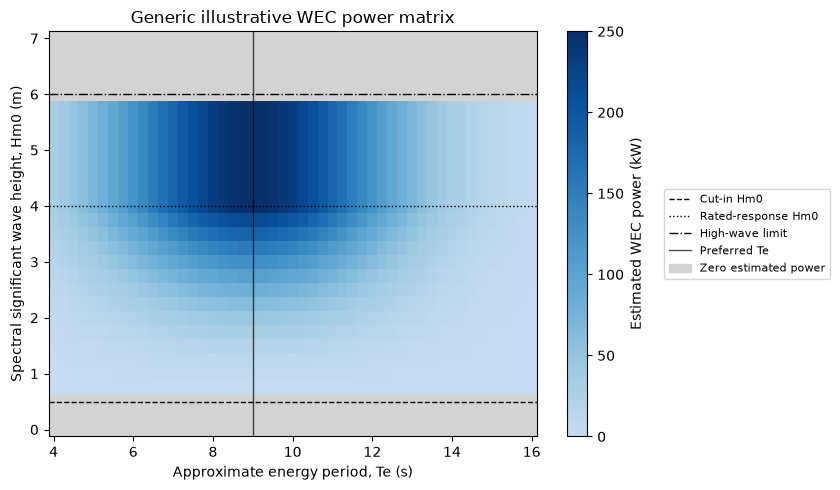

In [11]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Build a generic WEC response matrix over Hm0 and approximate Te.

hm0_grid = np.arange(0.0, 7.01, 0.25)
te_grid = np.arange(4.0, 16.01, 0.25)

Hm0_grid, Te_grid = np.meshgrid(hm0_grid, te_grid, indexing="ij")

rated_power_kw = wec_assumptions["rated_power_kw"]
cut_in_hm0_m = wec_assumptions["cut_in_hm0_m"]
rated_hm0_m = wec_assumptions["rated_hm0_m"]
high_wave_limit_hm0_m = wec_assumptions["storm_cutout_hm0_m"]
preferred_te_s = wec_assumptions["preferred_te_s"]
period_response_width_s = wec_assumptions["period_response_width_s"]

# Height response: increases from cut-in to rated-response height.
height_response = (Hm0_grid - cut_in_hm0_m) / (rated_hm0_m - cut_in_hm0_m)
height_response = np.clip(height_response, 0, 1)

# Squared response gives stronger growth with wave height.
height_response = height_response**2

# Period response: strongest near the preferred energy period.
period_response = np.exp(
    -0.5 * ((Te_grid - preferred_te_s) / period_response_width_s) ** 2
)

# Generic normalized power response.
generic_power_norm = height_response * period_response
generic_power_norm = np.clip(generic_power_norm, 0, 1)

# Convert to kW.
generic_power_matrix_kw = rated_power_kw * generic_power_norm

# Simple high-wave limiting rule for this illustrative model.
generic_power_matrix_kw[Hm0_grid >= high_wave_limit_hm0_m] = 0.0

generic_power_matrix_df = pd.DataFrame(
    generic_power_matrix_kw,
    index=np.round(hm0_grid, 2),
    columns=np.round(te_grid, 2),
)

# Mask zero-power cells so they appear grey.
matrix_for_plot = np.ma.masked_where(
    generic_power_matrix_kw <= 0,
    generic_power_matrix_kw,
)

# Light blue to very dark blue for positive power only.
blue_cmap = LinearSegmentedColormap.from_list(
    "light_to_dark_blues",
    plt.cm.Blues(np.linspace(0.25, 1.0, 256)),
)
blue_cmap.set_bad("lightgrey")

fig, ax = plt.subplots(figsize=(8.5, 5))

mesh = ax.pcolormesh(
    te_grid,
    hm0_grid,
    matrix_for_plot,
    shading="auto",
    cmap=blue_cmap,
    vmin=0,
    vmax=rated_power_kw,
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Estimated WEC power (kW)")

line_cut_in = ax.axhline(
    cut_in_hm0_m,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Cut-in Hm0",
)

line_rated = ax.axhline(
    rated_hm0_m,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Rated-response Hm0",
)

line_high = ax.axhline(
    high_wave_limit_hm0_m,
    color="black",
    linestyle="-.",
    linewidth=1,
    label="High-wave limit",
)

line_period = ax.axvline(
    preferred_te_s,
    color="black",
    linestyle="-",
    linewidth=1,
    alpha=0.7,
    label="Preferred Te",
)

zero_patch = Patch(
    facecolor="lightgrey",
    edgecolor="lightgrey",
    label="Zero estimated power",
)

ax.set_xlabel("Approximate energy period, Te (s)")
ax.set_ylabel("Spectral significant wave height, Hm0 (m)")
ax.set_title("Generic illustrative WEC power matrix")

ax.legend(
    handles=[line_cut_in, line_rated, line_high, line_period, zero_patch],
    loc="center left",
    bbox_to_anchor=(1.25, 0.5),
    fontsize=8,
)

fig.tight_layout()
figure_path = FIGURE_DIR / "02_generic_wec_power_matrix.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

The generic matrix shows the intended shape of the illustrative WEC response: zero estimated power in very small sea states and above the high-wave limit, with the strongest response around the preferred energy period and higher wave heights below the limiting threshold.

The grey areas therefore represent sea states where this simplified model assigns no electrical output. The blue area is not a validated device power curve; it is only the assumed response surface used to generate a transparent estimated power signal for the later forecasting and storage-smoothing notebooks.

### Mapping observed sea states to estimated WEC power

The generic matrix is now evaluated at each observed sea state using `hm0_m` and `te_approx_s`.

Missing input values remain missing. Very small waves and high-wave-limited conditions are assigned zero estimated power according to the simplified assumptions.

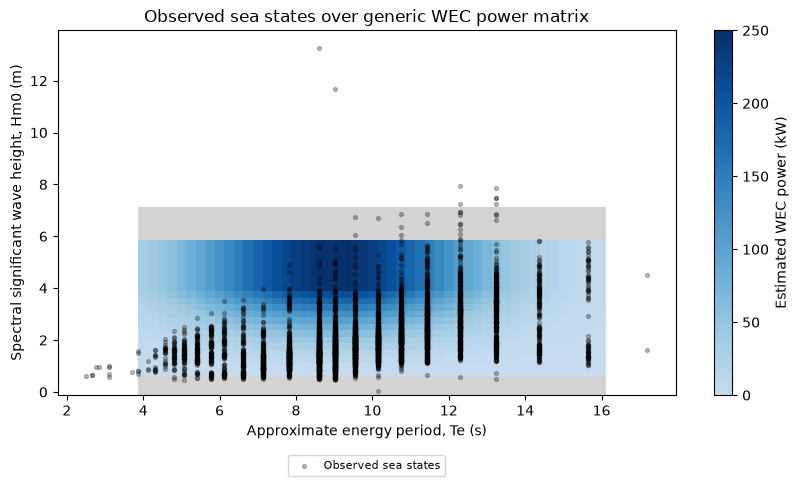

In [12]:
from scipy.interpolate import RegularGridInterpolator

# Interpolator over the generic WEC matrix.
power_interpolator = RegularGridInterpolator(
    points=(hm0_grid, te_grid),
    values=generic_power_matrix_kw,
    bounds_error=False,
    fill_value=np.nan,
)

# Flags for interpretation.
wec_df["matrix_input_missing_flag"] = wec_df[["hm0_m", "te_approx_s"]].isna().any(axis=1)

wec_df["te_outside_matrix_flag"] = (
    (wec_df["te_approx_s"] < te_grid.min())
    | (wec_df["te_approx_s"] > te_grid.max())
)

wec_df["hm0_outside_matrix_flag"] = (
    (wec_df["hm0_m"] < hm0_grid.min())
    | (wec_df["hm0_m"] > hm0_grid.max())
)

# Clip only for interpolation, while keeping outside-matrix flags.
hm0_eval = wec_df["hm0_m"].clip(hm0_grid.min(), hm0_grid.max())
te_eval = wec_df["te_approx_s"].clip(te_grid.min(), te_grid.max())

interp_points = np.column_stack([hm0_eval, te_eval])

wec_df["wec_power_kw_estimated"] = power_interpolator(interp_points)

# Keep missing inputs as missing.
wec_df.loc[
    wec_df["matrix_input_missing_flag"],
    "wec_power_kw_estimated",
] = np.nan

# Apply simple operating-envelope assumptions.
wec_df.loc[
    wec_df["hm0_m"] < wec_assumptions["cut_in_hm0_m"],
    "wec_power_kw_estimated",
] = 0.0

wec_df.loc[
    wec_df["hm0_m"] >= wec_assumptions["storm_cutout_hm0_m"],
    "wec_power_kw_estimated",
] = 0.0

wec_df["wec_power_norm_estimated"] = (
    wec_df["wec_power_kw_estimated"] / wec_assumptions["rated_power_kw"]
)

# Plot observed sea states over the generic matrix.
matrix_for_plot = np.ma.masked_where(
    generic_power_matrix_kw <= 0,
    generic_power_matrix_kw,
)

fig, ax = plt.subplots(figsize=(8.5, 5))

mesh = ax.pcolormesh(
    te_grid,
    hm0_grid,
    matrix_for_plot,
    shading="auto",
    cmap=blue_cmap,
    vmin=0,
    vmax=wec_assumptions["rated_power_kw"],
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Estimated WEC power (kW)")

observed_matrix_df = wec_df.dropna(subset=["hm0_m", "te_approx_s"])

ax.scatter(
    observed_matrix_df["te_approx_s"],
    observed_matrix_df["hm0_m"],
    s=8,
    color="black",
    alpha=0.25,
    label="Observed sea states",
)

ax.set_xlabel("Approximate energy period, Te (s)")
ax.set_ylabel("Spectral significant wave height, Hm0 (m)")
ax.set_title("Observed sea states over generic WEC power matrix")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    fontsize=8,
    frameon=True,
)

fig.tight_layout()
figure_path = FIGURE_DIR / "02_leixoes_observed_sea_states_over_wec_matrix.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

The observed Leixões sea states fall partly inside the non-zero region of the generic power matrix. This means the illustrative WEC model would produce estimated power for many moderate-to-energetic sea states, while very small waves and high-wave-limited conditions are assigned zero output. The scatter also shows that several observed extreme points lie outside the simple operating region, so those conditions should be interpreted cautiously rather than treated as normal power-production cases.

### WEC power output estimates

The generic power matrix gives two estimated WEC power-output variables:

* `wec_power_kw_estimated`: estimated electrical power in kW
* `wec_power_norm_estimated`: estimated power normalized by the assumed rated power

Here, the kW signal is plotted because it is easier to interpret physically. The normalized signal is kept in the dataset for later forecasting and comparison steps.

The wave-height panel shows the main `Hm0` thresholds used in the generic WEC assumptions: cut-in height, rated-response height, and high-wave limiting height.

The period panel shows approximate `Tp` guide lines derived from the `Te`-based assumptions. Since the matrix assumptions are defined using approximate energy period `Te`, the guide values are converted back to peak period using:

$$
T_p \approx \frac{T_e}{0.86}
$$

These period lines are only visual guides, not measured device limits.


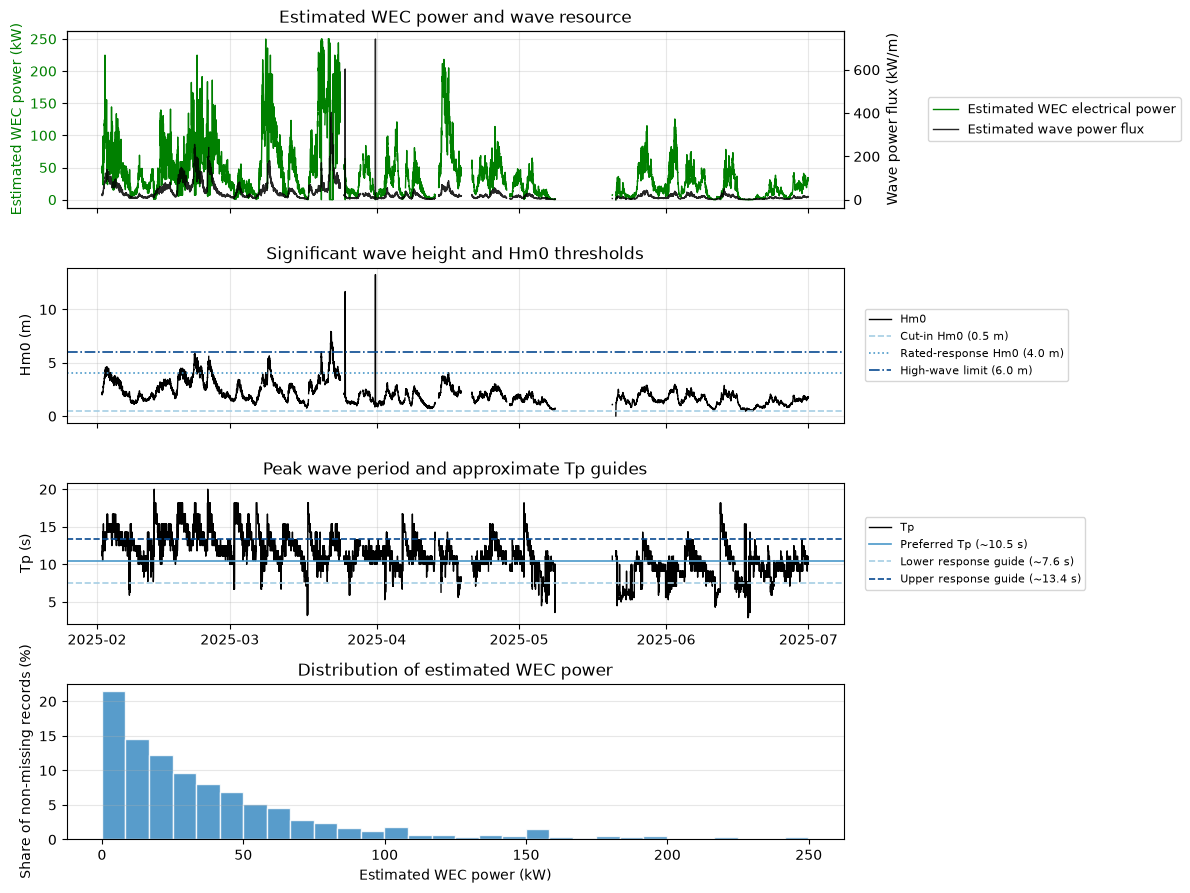

In [13]:
power_plot_df = wec_df.copy()

from matplotlib.lines import Line2D

fig = plt.figure(figsize=(14, 10.5))
gs = fig.add_gridspec(
    nrows=4,
    ncols=1,
    height_ratios=[1.25, 1.1, 1.0, 1.1],
    hspace=0.38,
)

ax_power = fig.add_subplot(gs[0, 0])
ax_hm0 = fig.add_subplot(gs[1, 0], sharex=ax_power)
ax_tp = fig.add_subplot(gs[2, 0], sharex=ax_power)
ax_hist = fig.add_subplot(gs[3, 0])

# --- 1) Estimated WEC power + wave resource time series ---
line_wec, = ax_power.plot(
    power_plot_df["time"],
    power_plot_df["wec_power_kw_estimated"],
    color="green",
    linewidth=1.0,
    label="Estimated WEC electrical power",
)

ax_power.set_ylabel("Estimated WEC power (kW)", color="green")
ax_power.tick_params(axis="y", labelcolor="green")
ax_power.set_title("Estimated WEC power and wave resource")
ax_power.grid(True, alpha=0.3)

ax_resource = ax_power.twinx()
line_resource, = ax_resource.plot(
    power_plot_df["time"],
    power_plot_df["wave_power_flux_kw_m_estimated"],
    color="black",
    linewidth=1.0,
    alpha=0.85,
    label="Estimated wave power flux",
)

ax_resource.set_ylabel("Wave power flux (kW/m)", color="black")
ax_resource.tick_params(axis="y", labelcolor="black")

ax_power.legend(
    handles=[line_wec, line_resource],
    loc="center left",
    bbox_to_anchor=(1.10, 0.5),
    ncol=1,
    frameon=True,
    fontsize=9,
)

# --- 2) Hm0 time series with WEC height thresholds ---
line_hm0, = ax_hm0.plot(
    power_plot_df["time"],
    power_plot_df["hm0_m"],
    color="black",
    linewidth=1.0,
    label="Hm0",
)

line_cutin = ax_hm0.axhline(
    wec_assumptions["cut_in_hm0_m"],
    color=plt.cm.Blues(0.35),
    linestyle="--",
    linewidth=1.2,
    label=f"Cut-in Hm0 ({wec_assumptions['cut_in_hm0_m']:.1f} m)",
)

line_rated = ax_hm0.axhline(
    wec_assumptions["rated_hm0_m"],
    color=plt.cm.Blues(0.60),
    linestyle=":",
    linewidth=1.2,
    label=f"Rated-response Hm0 ({wec_assumptions['rated_hm0_m']:.1f} m)",
)

line_high = ax_hm0.axhline(
    wec_assumptions["storm_cutout_hm0_m"],
    color=plt.cm.Blues(0.90),
    linestyle="-.",
    linewidth=1.2,
    label=f"High-wave limit ({wec_assumptions['storm_cutout_hm0_m']:.1f} m)",
)

ax_hm0.set_ylabel("Hm0 (m)")
ax_hm0.set_title("Significant wave height and Hm0 thresholds")
ax_hm0.grid(True, alpha=0.3)

ax_hm0.legend(
    handles=[line_hm0, line_cutin, line_rated, line_high],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True,
    fontsize=8,
)

# --- 3) Tp time series with approximate period guides derived from Te assumptions ---
preferred_tp_s = wec_assumptions["preferred_te_s"] / te_from_tp_factor
lower_tp_s = (
    wec_assumptions["preferred_te_s"] - wec_assumptions["period_response_width_s"]
) / te_from_tp_factor
upper_tp_s = (
    wec_assumptions["preferred_te_s"] + wec_assumptions["period_response_width_s"]
) / te_from_tp_factor

line_tp, = ax_tp.plot(
    power_plot_df["time"],
    power_plot_df["tp_s"],
    color="black",
    linewidth=1.0,
    label="Tp",
)

line_tp_pref = ax_tp.axhline(
    preferred_tp_s,
    color=plt.cm.Blues(0.60),
    linestyle="-",
    linewidth=1.2,
    label=f"Preferred Tp (~{preferred_tp_s:.1f} s)",
)

line_tp_low = ax_tp.axhline(
    lower_tp_s,
    color=plt.cm.Blues(0.35),
    linestyle="--",
    linewidth=1.2,
    label=f"Lower response guide (~{lower_tp_s:.1f} s)",
)

line_tp_high = ax_tp.axhline(
    upper_tp_s,
    color=plt.cm.Blues(0.90),
    linestyle="--",
    linewidth=1.2,
    label=f"Upper response guide (~{upper_tp_s:.1f} s)",
)

ax_tp.set_ylabel("Tp (s)")
ax_tp.set_title("Peak wave period and approximate Tp guides")
ax_tp.grid(True, alpha=0.3)

ax_tp.legend(
    handles=[line_tp, line_tp_pref, line_tp_low, line_tp_high],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=True,
    fontsize=8,
)

# --- 4) Estimated WEC power distribution ---
power_kw = power_plot_df["wec_power_kw_estimated"].dropna()
power_weights = np.ones_like(power_kw) * 100 / len(power_kw)

ax_hist.hist(
    power_kw,
    bins=30,
    weights=power_weights,
    color=plt.cm.Blues(0.65),
    edgecolor="white",
    alpha=0.85,
)

ax_hist.set_xlabel("Estimated WEC power (kW)")
ax_hist.set_ylabel("Share of non-missing records (%)")
ax_hist.set_title("Distribution of estimated WEC power")
ax_hist.grid(True, axis="y", alpha=0.3)

# Hide upper x tick labels
plt.setp(ax_power.get_xticklabels(), visible=False)
plt.setp(ax_hm0.get_xticklabels(), visible=False)

# Leave room on the right for legends
fig.subplots_adjust(right=0.68)
figure_path = FIGURE_DIR / "02_leixoes_wec_power_output_estimates.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

The estimated WEC power signal broadly follows the available wave-resoure proxy, but the two are not identical because the generic WEC matrix also depends on the assumed height and period response. Higher estimated power appears mainly when wave heights are above the cut-in level and when peak periods are close to the approximate response range. The distribution shows that low-to-moderate estimated output is most frequent, while near-rated values occur only during a smaller number of energetic sea states.

In [14]:
import json
from pathlib import Path

# Output paths
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

generic_wec_model_id = "generic_wec_power_matrix_v1"

wec_timeseries_path = PROCESSED_DIR / "leixoes_wec_power_30min_estimated.parquet"
power_matrix_path = PROCESSED_DIR / f"{generic_wec_model_id}.parquet"
metadata_path = PROCESSED_DIR / f"{generic_wec_model_id}_metadata.json"

# -------------------------------------------------------------------
# 1. Save estimated WEC power time series
# -------------------------------------------------------------------

wec_df["generic_wec_model_id"] = generic_wec_model_id

timeseries_columns = [
    "time",
    "latitude",
    "longitude",
    "hm0_m",
    "tp_s",
    "tm02_s",
    "tz_s",
    "tmax_s",
    "thmax_s",
    "h13_m",
    "hmax_m",
    "dir_peak_deg",
    "spread_peak_deg",
    "te_approx_s",
    "wave_power_flux_kw_m_estimated",
    "wec_power_kw_estimated",
    "wec_power_norm_estimated",
    "sea_state_hm0_band",
    "high_wave_flag",
    "very_rough_or_higher_flag",
    "matrix_input_missing_flag",
    "te_outside_matrix_flag",
    "hm0_outside_matrix_flag",
    "generic_wec_model_id",
]

# Keep only columns that exist in the current dataframe.
timeseries_columns = [col for col in timeseries_columns if col in wec_df.columns]

wec_timeseries_df = wec_df[timeseries_columns].copy()
wec_timeseries_df.to_parquet(wec_timeseries_path, index=False)

# -------------------------------------------------------------------
# 2. Save generic WEC power matrix in tidy/long format
# -------------------------------------------------------------------

power_matrix_tidy_df = pd.DataFrame(
    {
        "hm0_m": Hm0_grid.ravel(),
        "te_s": Te_grid.ravel(),
        "wec_power_kw_estimated": generic_power_matrix_kw.ravel(),
    }
)

power_matrix_tidy_df["wec_power_norm_estimated"] = (
    power_matrix_tidy_df["wec_power_kw_estimated"] / wec_assumptions["rated_power_kw"]
)

power_matrix_tidy_df["generic_wec_model_id"] = generic_wec_model_id

power_matrix_tidy_df.to_parquet(power_matrix_path, index=False)

# -------------------------------------------------------------------
# 3. Save assumptions and metadata
# -------------------------------------------------------------------

metadata = {
    "model_id": generic_wec_model_id,
    "created_by_notebook": "02_wec_power_estimation.ipynb",
    "input_file": "../data/processed/leixoes_wave_30min_processed.parquet",
    "output_timeseries_file": str(wec_timeseries_path),
    "output_power_matrix_file": str(power_matrix_path),
    "method_summary": (
        "Simplified generic power-matrix-style WEC power estimate using Hm0 "
        "and approximate Te. The model is illustrative and not calibrated to "
        "a specific WEC device."
    ),
    "wec_assumptions": {
        "rated_power_kw": float(wec_assumptions["rated_power_kw"]),
        "cut_in_hm0_m": float(wec_assumptions["cut_in_hm0_m"]),
        "rated_hm0_m": float(wec_assumptions["rated_hm0_m"]),
        "high_wave_limit_hm0_m": float(wec_assumptions["storm_cutout_hm0_m"]),
        "preferred_te_s": float(wec_assumptions["preferred_te_s"]),
        "period_response_width_s": float(wec_assumptions["period_response_width_s"]),
    },
    "period_assumption": {
        "te_from_tp_factor": float(te_from_tp_factor),
        "formula": "Te ≈ 0.86 * Tp",
    },
    "wave_power_flux_assumption": {
        "formula": "J_kW_m ≈ 0.49 * Hm0^2 * Te",
        "note": "Deep-water approximation used as a wave-resource diagnostic.",
    },
    "saved_columns": timeseries_columns,
    "references": [
        {
            "name": "MHKiT wave example — power matrices",
            "url": "https://mhkit-software.github.io/MHKiT/wave_example.html",
        },
        {
            "name": "MHKiT wave performance API",
            "url": "https://mhkit-software.github.io/MHKiT/mhkit-python/api.wave.html",
        },
        {
            "name": "Marine Energy Atlas — power matrix description",
            "url": "https://maps.nlr.gov/marine-energy-atlas/data-viewer/power-matrix",
        },
        {
            "name": "Pelamis P-750 brochure",
            "url": "https://bravenewclimate.com/files/media/pelamisbrochure.pdf",
        },
        {
            "name": "Guillou 2020 — estimating wave energy flux from Hs and Tp",
            "url": "https://doi.org/10.1016/j.renene.2020.03.124",
        },
    ],
    "important_limitations": [
        "The estimated WEC power signal is illustrative.",
        "The model is not calibrated to a specific device.",
        "The model is not a detailed hydrodynamic or wave-to-wire simulation.",
        "Directionality, control dynamics, PTO behaviour, mooring effects, and array effects are not modelled.",
    ],
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

# -------------------------------------------------------------------
# 4. Print save summary
# -------------------------------------------------------------------

print("Saved WEC power-estimation outputs:")
print(f"- Time series: {wec_timeseries_path}")
print(f"- Generic power matrix: {power_matrix_path}")
print(f"- Metadata: {metadata_path}")

print()
print("Main estimated output columns:")
print("- wec_power_kw_estimated")
print("- wec_power_norm_estimated")
print("- wave_power_flux_kw_m_estimated")
print("- te_approx_s")

Saved WEC power-estimation outputs:
- Time series: ../data/processed/leixoes_wec_power_30min_estimated.parquet
- Generic power matrix: ../data/processed/generic_wec_power_matrix_v1.parquet
- Metadata: ../data/processed/generic_wec_power_matrix_v1_metadata.json

Main estimated output columns:
- wec_power_kw_estimated
- wec_power_norm_estimated
- wave_power_flux_kw_m_estimated
- te_approx_s
